In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.metrics.pairwise import cosine_similarity


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paramaggarwal/fashion-product-images-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fashion-product-images-dataset' dataset.
Path to dataset files: /kaggle/input/fashion-product-images-dataset


In [3]:
import os

print("Files in Dataset Folder:\n")

for item in os.listdir(path):
    print(item)

Files in Dataset Folder:

fashion-dataset


In [4]:
import os

image_folder = None
csv_file = None

for root, dirs, files in os.walk(path):

    if "images" in dirs:
        image_folder = os.path.join(root, "images")

    if "styles.csv" in files:
        csv_file = os.path.join(root, "styles.csv")

print("Image Folder :", image_folder)
print("CSV File     :", csv_file)

Image Folder : /kaggle/input/fashion-product-images-dataset/fashion-dataset/fashion-dataset/images
CSV File     : /kaggle/input/fashion-product-images-dataset/fashion-dataset/fashion-dataset/styles.csv


In [5]:
# Load styles.csv

df = pd.read_csv(csv_file, on_bad_lines="skip")

print("Dataset Shape :", df.shape)

df.head()

Dataset Shape : (44424, 10)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [7]:
print("Dataset Information\n")

print("Total Images :", len(df))
print("Unique Categories :", df["masterCategory"].nunique())
print("Unique Sub Categories :", df["subCategory"].nunique())
print("Unique Article Types :", df["articleType"].nunique())

Dataset Information

Total Images : 44424
Unique Categories : 7
Unique Sub Categories : 45
Unique Article Types : 143


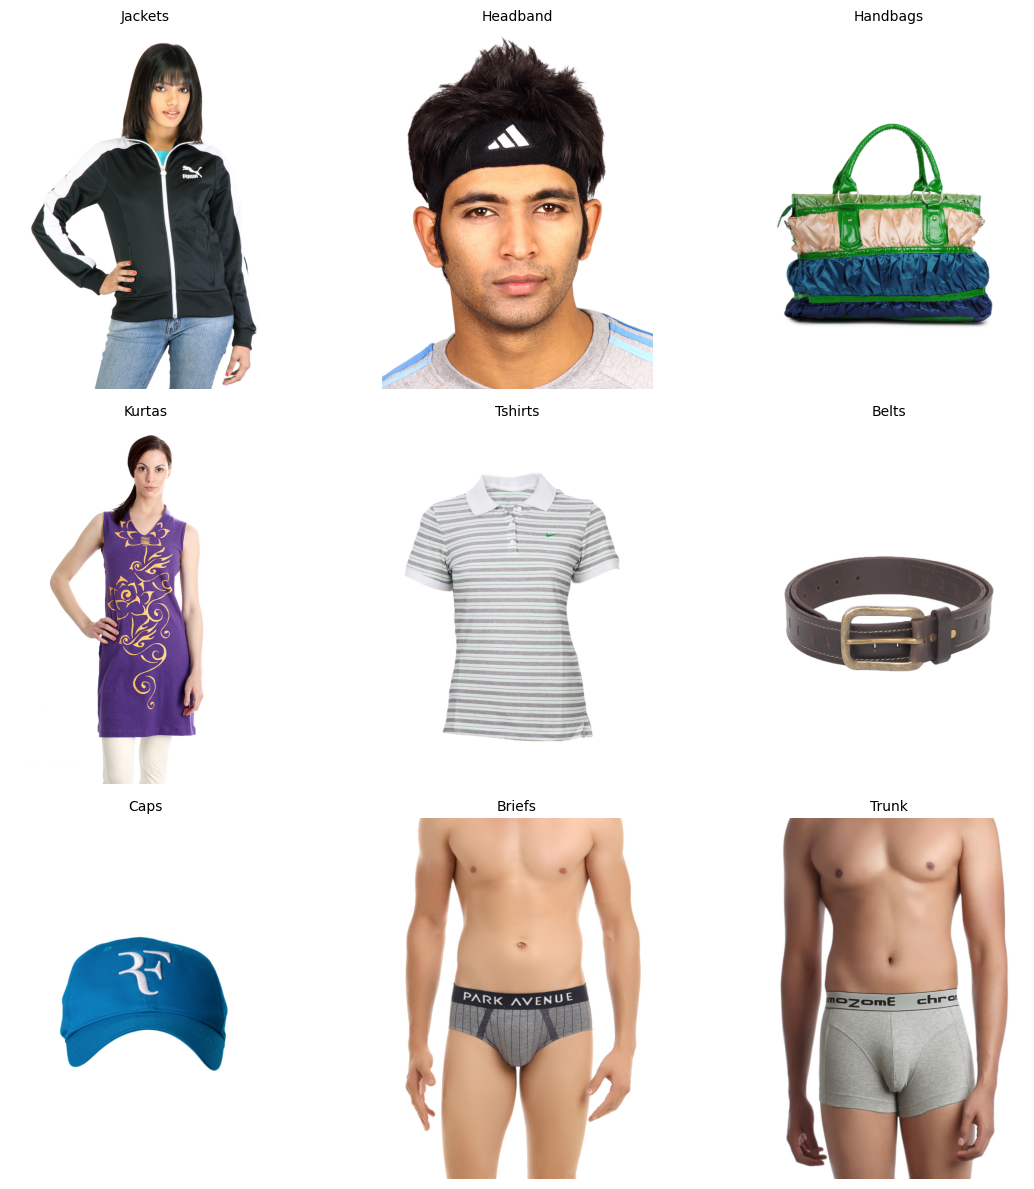

In [8]:
import random

sample_df = df.sample(9, random_state=42)

plt.figure(figsize=(12, 12))

for i, (_, row) in enumerate(sample_df.iterrows()):

    image_path = os.path.join(image_folder, f"{row['id']}.jpg")

    if os.path.exists(image_path):

        image = Image.open(image_path)

        plt.subplot(3, 3, i + 1)
        plt.imshow(image)
        plt.title(row["articleType"], fontsize=10)
        plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
valid_data = []

for _, row in df.iterrows():

    image_path = os.path.join(image_folder, f"{row['id']}.jpg")

    if os.path.exists(image_path):
        valid_data.append({
            "id": row["id"],
            "image_path": image_path,
            "label": row["articleType"]
        })

valid_df = pd.DataFrame(valid_data)

print("Valid Images :", len(valid_df))

valid_df.head()

Valid Images : 44419


,id,image_path,label
0,15970,/kaggle/input/fashion-product-images-dataset/f...,Shirts
1,39386,/kaggle/input/fashion-product-images-dataset/f...,Jeans
2,59263,/kaggle/input/fashion-product-images-dataset/f...,Watches
3,21379,/kaggle/input/fashion-product-images-dataset/f...,Track Pants
4,53759,/kaggle/input/fashion-product-images-dataset/f...,Tshirts


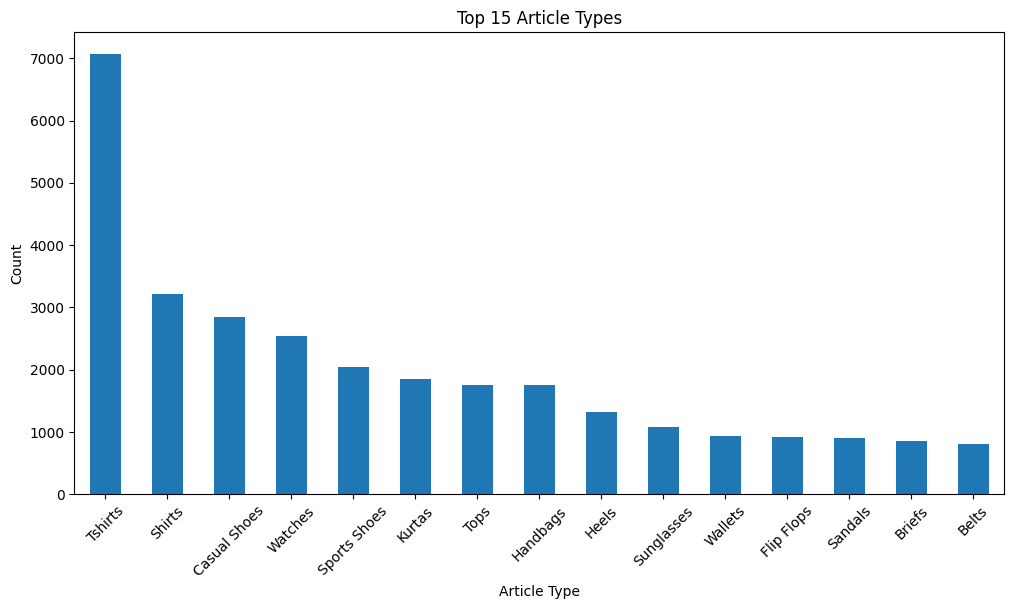

In [10]:
plt.figure(figsize=(12,6))

valid_df["label"].value_counts().head(15).plot(kind="bar")

plt.title("Top 15 Article Types")
plt.xlabel("Article Type")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [11]:
# Select images for training

train_df = valid_df.sample(n=12000, random_state=42).reset_index(drop=True)

print("Training Images :", len(train_df))

train_df.head()

Training Images : 12000


,id,image_path,label
0,16947,/kaggle/input/fashion-product-images-dataset/f...,Sunglasses
1,40524,/kaggle/input/fashion-product-images-dataset/f...,Watches
2,36313,/kaggle/input/fashion-product-images-dataset/f...,Tshirts
3,44188,/kaggle/input/fashion-product-images-dataset/f...,Flip Flops
4,33859,/kaggle/input/fashion-product-images-dataset/f...,Flip Flops


In [12]:
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

In [13]:
def load_image(image_path):

    image = tf.io.read_file(image_path)

    image = tf.image.decode_jpeg(image, channels=3)

    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    image = preprocess_input(image)

    return image

In [14]:
image_paths = train_df["image_path"].values

train_dataset = tf.data.Dataset.from_tensor_slices(image_paths)

train_dataset = train_dataset.map(load_image,
                                  num_parallel_calls=AUTOTUNE)

train_dataset = train_dataset.batch(BATCH_SIZE)

train_dataset = train_dataset.prefetch(AUTOTUNE)

print(train_dataset)

<_PrefetchDataset element_spec=TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None)>


In [15]:
for batch in train_dataset.take(1):

    print(batch.shape)

(32, 224, 224, 3)


In [16]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

train_df["label"] = label_encoder.fit_transform(train_df["label"])

NUM_CLASSES = train_df["label"].nunique()

print("Number of Classes :", NUM_CLASSES)

Number of Classes : 128


In [17]:
image_paths = train_df["image_path"].values
labels = train_df["label"].values

def load_image(image_path, label):

    image = tf.io.read_file(image_path)

    image = tf.image.decode_jpeg(image, channels=3)

    image = tf.image.resize(image, (224,224))

    image = preprocess_input(image)

    return image, label


train_dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))

train_dataset = train_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_dataset = train_dataset.shuffle(1000)

train_dataset = train_dataset.batch(32)

train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

In [18]:
base_model = tf.keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224,224,3))

x = base_model(inputs, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dense(512, activation="relu")(x)

x = tf.keras.layers.Dropout(0.3)(x)

embedding = tf.keras.layers.Dense(
    128,
    activation=None,
    name="embedding_layer"
)(x)

outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(embedding)

model = tf.keras.Model(inputs, outputs)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_layer (Dense)         │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,996,032 (11.43 MB)

 Trainable params: 738,048 (2.82 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [19]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [20]:
history = model.fit(
    train_dataset,
    epochs=5
)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 182s 398ms/step - accuracy: 0.7075 - loss: 1.1408
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 148s 362ms/step - accuracy: 0.8010 - loss: 0.6583
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 196s 347ms/step - accuracy: 0.8313 - loss: 0.5271
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 152s 374ms/step - accuracy: 0.8522 - loss: 0.4465
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 142s 347ms/step - accuracy: 0.8742 - loss: 0.3659


In [21]:
model.save("image_similarity_model.keras")

In [22]:
embedding_model = tf.keras.Model(
    inputs=model.input,
    outputs=model.get_layer("embedding_layer").output
)

embedding_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_layer (Dense)         │ (None, 128)            │        65,664 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,979,520 (11.37 MB)

 Trainable params: 721,536 (2.75 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [23]:
all_image_paths = valid_df["image_path"].tolist()

embeddings = []

for image_path in tqdm(all_image_paths):

    image = tf.keras.preprocessing.image.load_img(
        image_path,
        target_size=(224,224)
    )

    image = tf.keras.preprocessing.image.img_to_array(image)

    image = preprocess_input(image)

    image = np.expand_dims(image, axis=0)

    embedding = embedding_model.predict(
        image,
        verbose=0
    )

    embeddings.append(embedding[0])

embeddings = np.array(embeddings)

print("Embedding Shape :", embeddings.shape)

100%|██████████| 44419/44419 [1:21:27<00:00,  9.09it/s]


Embedding Shape : (44419, 128)


In [ ]:
np.save("image_embeddings.npy", embeddings)

np.save("image_paths.npy", all_image_paths)

embedding_model.save("embedding_model.keras")

In [ ]:
image = tf.keras.preprocessing.image.load_img(
    query_image,
    target_size=(224,224)
)

image = tf.keras.preprocessing.image.img_to_array(image)

image = preprocess_input(image)

image = np.expand_dims(image, axis=0)

query_embedding = embedding_model.predict(
    image,
    verbose=0
)

In [27]:
similarity = cosine_similarity(
    query_embedding,
    embeddings
)

similarity = similarity.flatten()

top_indices = np.argsort(similarity)[::-1][1:6]

top_indices

array([40199, 38797, 26004, 43389, 17340])

In [32]:
print("Image Similarity Search Results")

print(f"Training Images      : {len(train_df)}")
print(f"Database Images      : {len(valid_df)}")
print(f"Embedding Dimension  : {embeddings.shape[1]}")
print(f"Training Accuracy    : {history.history['accuracy'][-1]:.4f}")
print(f"Training Loss        : {history.history['loss'][-1]:.4f}")

Image Similarity Search Results
Training Images      : 12000
Database Images      : 44419
Embedding Dimension  : 128
Training Accuracy    : 0.8742
Training Loss        : 0.3659
